## Random Forest Classification

In [125]:
# Import  libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [126]:
# Load Titanic dataset
df = pd.read_csv("Titanic_dataset.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,0,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [127]:
# Display first 5 rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [128]:
# Dataset shape
df.shape

(418, 12)

In [129]:
# Column names
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [130]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [131]:
# Statistical summary
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,0.363636,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.481622,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,0.000000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,0.000000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,1.000000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,1.000000,3.000000,76.000000,8.000000,9.000000,512.329200


In [132]:
# Check missing values
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [133]:
# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

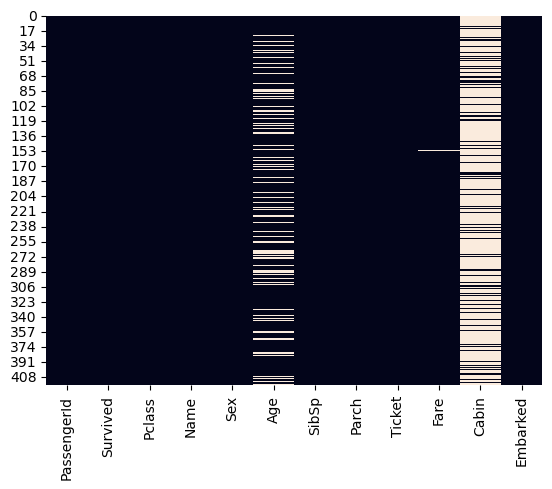

In [134]:
# Visualize missing data
sns.heatmap(df.isnull(), cbar=False)
plt.show()

In [135]:
# Fill missing Age with median
df["Age"] = df["Age"].fillna(df["Age"].median())

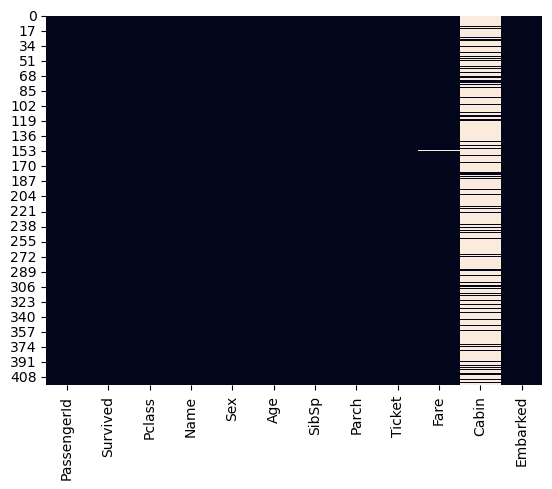

In [136]:
# Visualize after filling missing values 
sns.heatmap(df.isnull(), cbar=False)
plt.show()

In [137]:
# Fill missing Fare with mode
df["Fare"] = df["Fare"].fillna(df["Fare"].mode()[0])

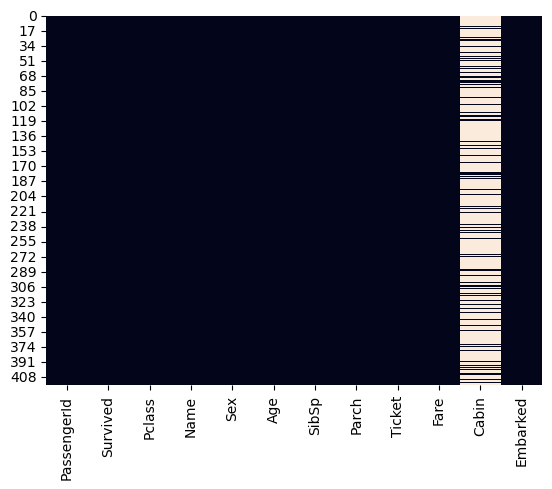

In [138]:
# Visualize after filling missing values 
sns.heatmap(df.isnull(), cbar=False)
plt.show()

In [139]:
# Drop Cabin column
df.drop("Cabin", axis=1, inplace=True)

In [140]:
# Check missing values again
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

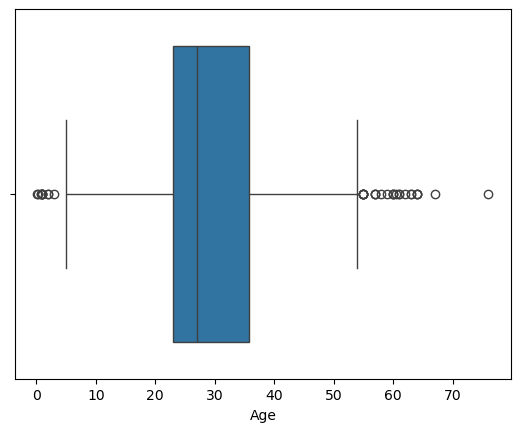

In [141]:
# Boxplot for Age
sns.boxplot(x=df["Age"])
plt.show()

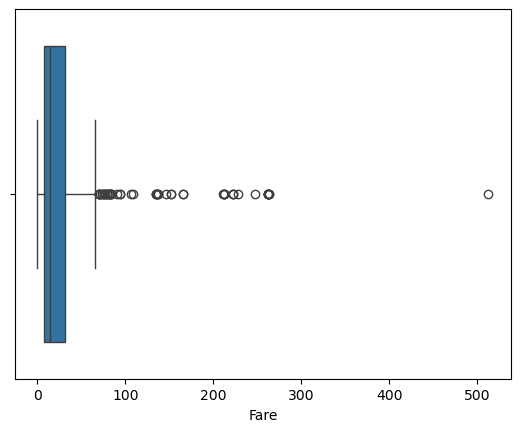

In [96]:
# Boxplot for Fare
sns.boxplot(x=df["Fare"])
plt.show()

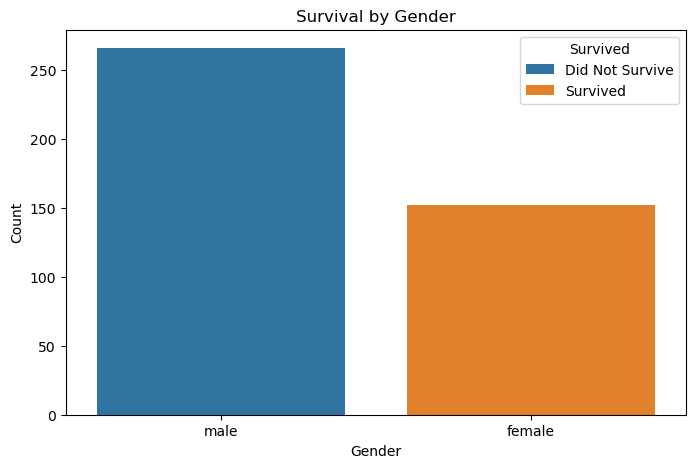

In [145]:
# Survival by gender
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Sex",
    hue="Survived"
)

plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.legend(
    title="Survived",
    labels=["Did Not Survive", "Survived"]
)

plt.show()

In [97]:
num_cols = df.select_dtypes(include=np.number).columns

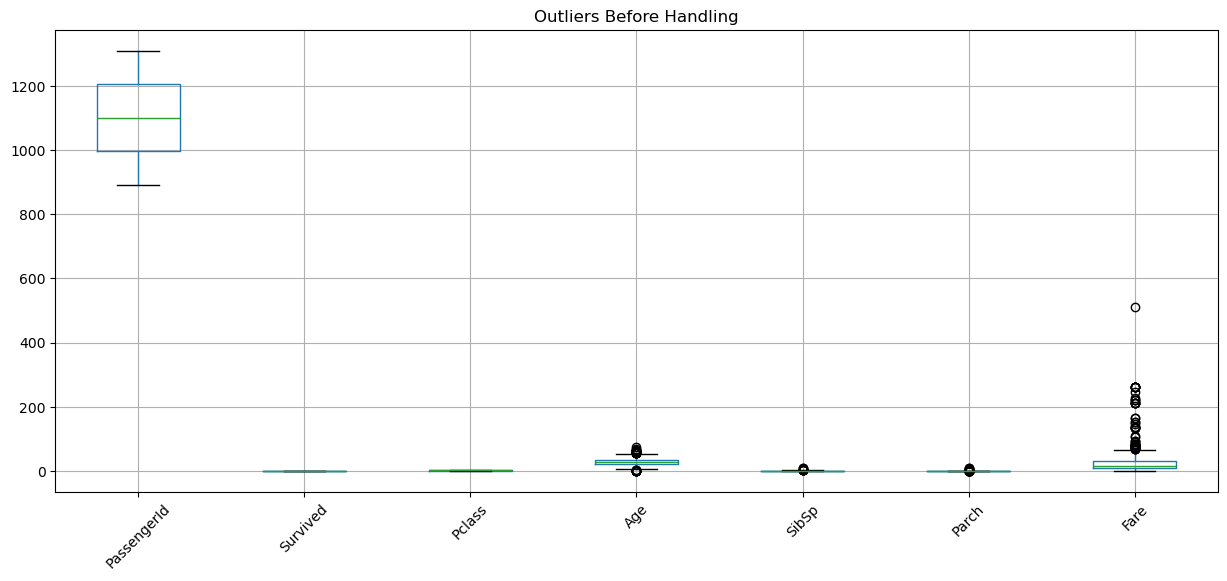

In [98]:
plt.figure(figsize=(15, 6))
df[num_cols].boxplot()
plt.title("Outliers Before Handling")
plt.xticks(rotation=45)
plt.show()

In [99]:
# Remove outliers from all numeric columns
for col in num_cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower = Q1 - (1.5 * IQR)
    upper = Q3 + (1.5 * IQR)
    
    df = df[
        (df[col] >= lower) &
        (df[col] <= upper)
    ]

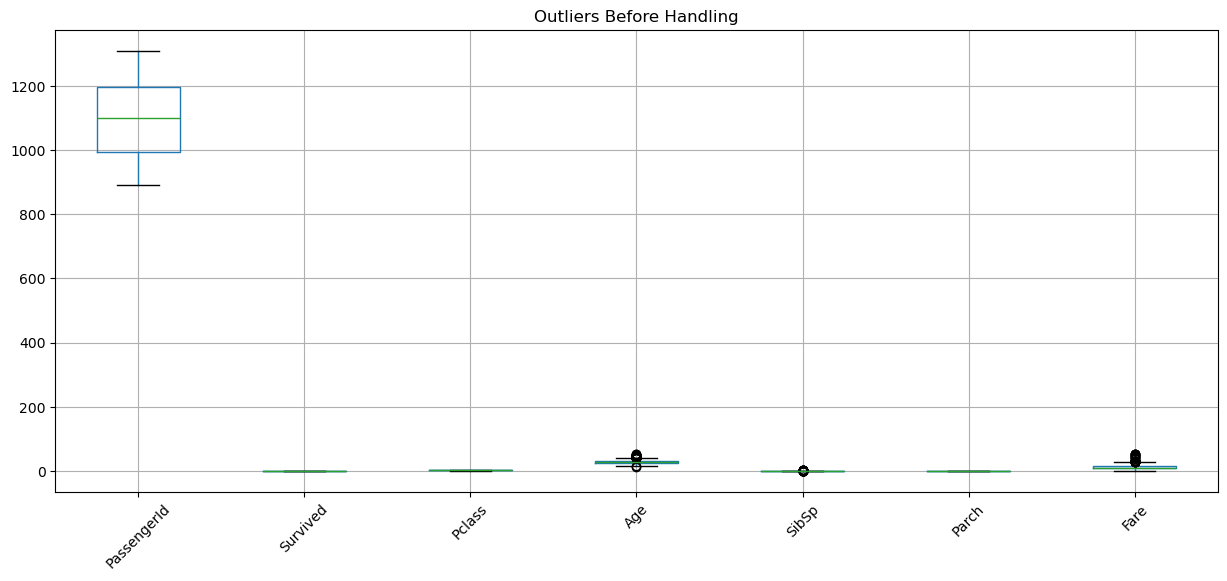

In [100]:
plt.figure(figsize=(15, 6))
df[num_cols].boxplot()
plt.title("Outliers Before Handling")
plt.xticks(rotation=45)
plt.show()

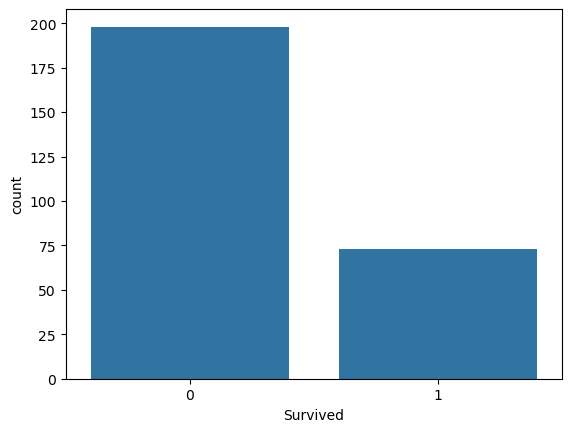

In [101]:
# Survival count
sns.countplot(x="Survived", data=df)
plt.show()

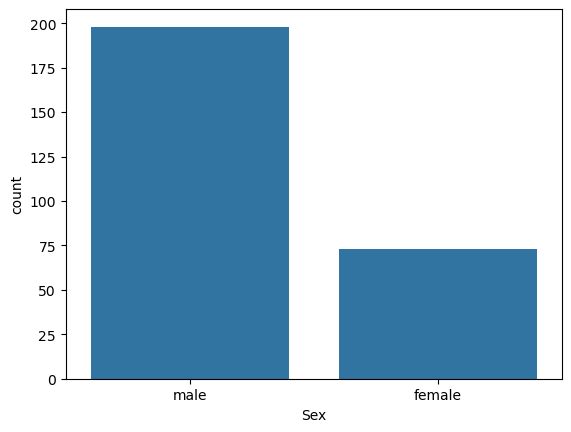

In [102]:
# Gender count
sns.countplot(x="Sex", data=df)
plt.show()

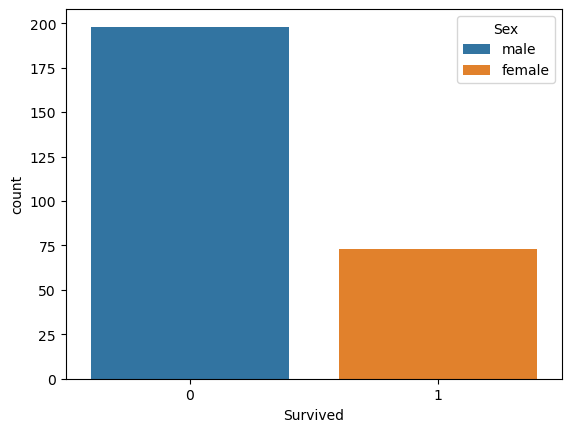

In [103]:
# Survival by gender
sns.countplot(x="Survived", hue="Sex", data=df)
plt.show()

In [104]:
# Remove unwanted columns
df.drop(["PassengerId", "Name", "Ticket"], axis=1, inplace=True)

In [105]:
# Convert categorical columns
df = pd.get_dummies(df, drop_first=True)

In [106]:
# Display processed dataset
df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,34.5,0,0,7.8292,True,True,False
1,1,3,47.0,1,0,7.0000,False,False,True
3,0,3,27.0,0,0,8.6625,True,False,True
5,0,3,14.0,0,0,9.2250,True,False,True
6,1,3,30.0,0,0,7.6292,False,True,False


In [107]:
# Define X and y
X = df.drop("Survived", axis=1)
y = df["Survived"]

In [108]:
# Import standard scaler
from sklearn.preprocessing import StandardScaler
# Apply feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
scaler


,copy,True
,with_mean,True
,with_std,True


In [109]:
X_scaled

array([[ 0.70415496,  0.83358461, -0.41468834, ...,  0.60719591,
         2.33503339, -1.41813649],
       [ 0.70415496,  2.47340336,  1.7464759 , ..., -1.64691492,
        -0.4282594 ,  0.70515074],
       [ 0.70415496, -0.15030663, -0.41468834, ...,  0.60719591,
        -0.4282594 ,  0.70515074],
       ...,
       [ 0.70415496, -0.15030663, -0.41468834, ...,  0.60719591,
        -0.4282594 ,  0.70515074],
       [ 0.70415496,  1.35832661, -0.41468834, ...,  0.60719591,
        -0.4282594 ,  0.70515074],
       [ 0.70415496, -0.15030663, -0.41468834, ...,  0.60719591,
        -0.4282594 ,  0.70515074]], shape=(271, 8))

In [110]:
# Split train and test data
from sklearn.model_selection import train_test_split
# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [111]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((216, 8), (55, 8), (216,), (55,))

In [112]:
# Import random forest classifier
from sklearn.ensemble import RandomForestClassifier
# Train random forest model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)
model


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [113]:
# Predict test data
y_pred = model.predict(X_test)
y_pred

array([0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0])

In [114]:
# Import evaluation metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
# Accuracy score
accuracy_score(y_test, y_pred)
# Confusion matrix
confusion_matrix(y_test, y_pred)
# Classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        40
           1       1.00      1.00      1.00        15

    accuracy                           1.00        55
   macro avg       1.00      1.00      1.00        55
weighted avg       1.00      1.00      1.00        55



In [115]:
# Compare actual and predicted values
result = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

result.head(10)

,Actual,Predicted
46,0,0
172,0,0
115,0,0
195,0,0
295,0,0
209,0,0
315,1,1
70,1,1
245,0,0
376,1,1


In [116]:
# Check feature importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance.sort_values(by="Importance", ascending=False)

,Feature,Importance
5,Sex_male,0.817198
4,Fare,0.060758
1,Age,0.044485
6,Embarked_Q,0.030570
7,Embarked_S,0.017234
2,SibSp,0.015944
0,Pclass,0.013813
3,Parch,0.000000


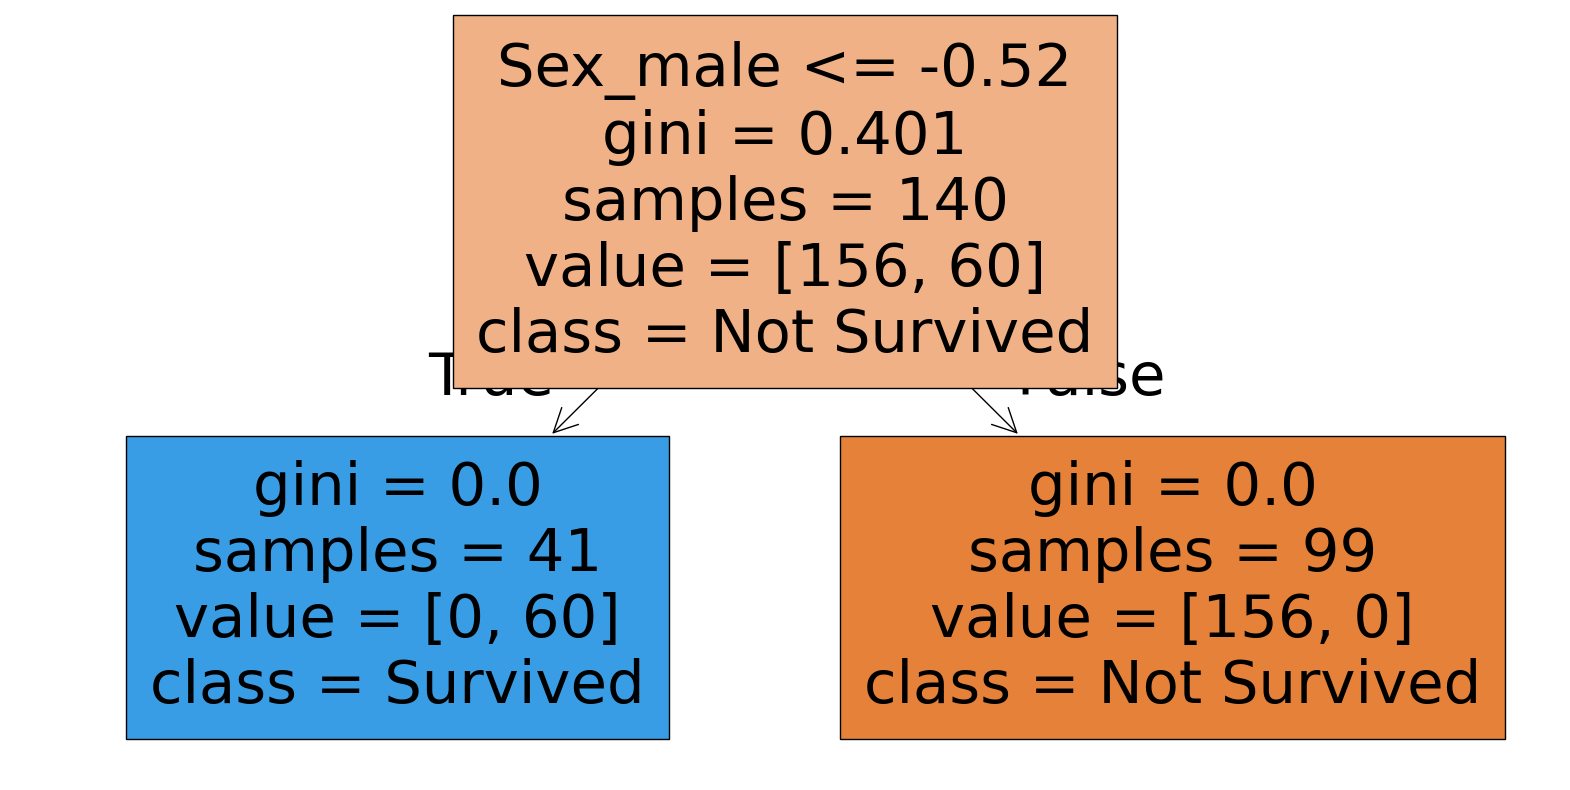

In [117]:
# Import tree visualization
from sklearn import tree
# Plot one tree from forest
plt.figure(figsize=(20,10))

tree.plot_tree(
    model.estimators_[0],
    filled=True,
    feature_names=X.columns,
    class_names=["Not Survived", "Survived"]
)

plt.show()

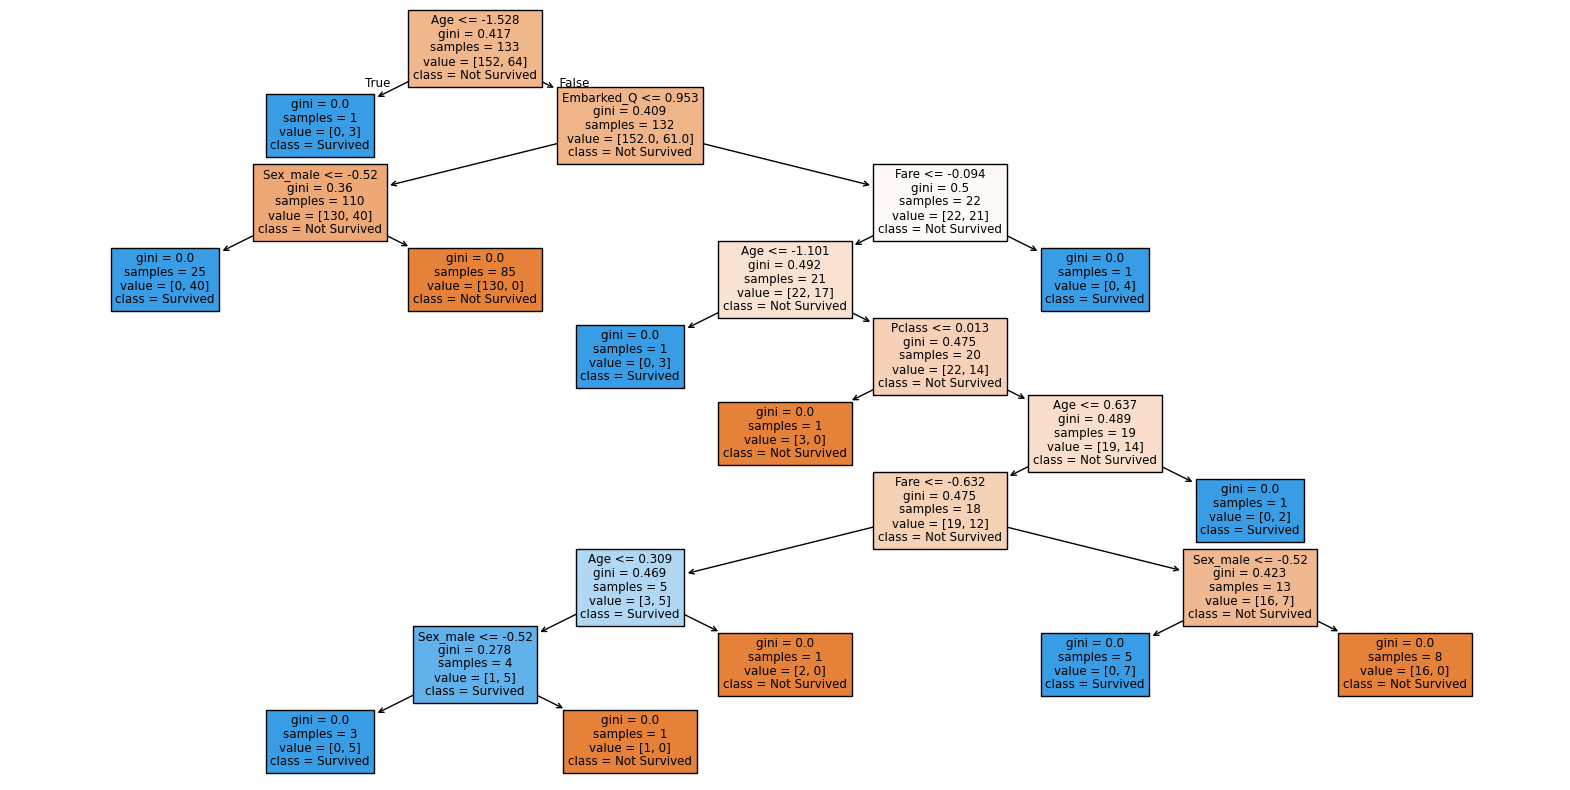

In [118]:
# Import tree visualization
from sklearn import tree
# Plot one tree from forest
plt.figure(figsize=(20,10))

tree.plot_tree(
    model.estimators_[5],
    filled=True,
    feature_names=X.columns,
    class_names=["Not Survived", "Survived"]
)

plt.show()

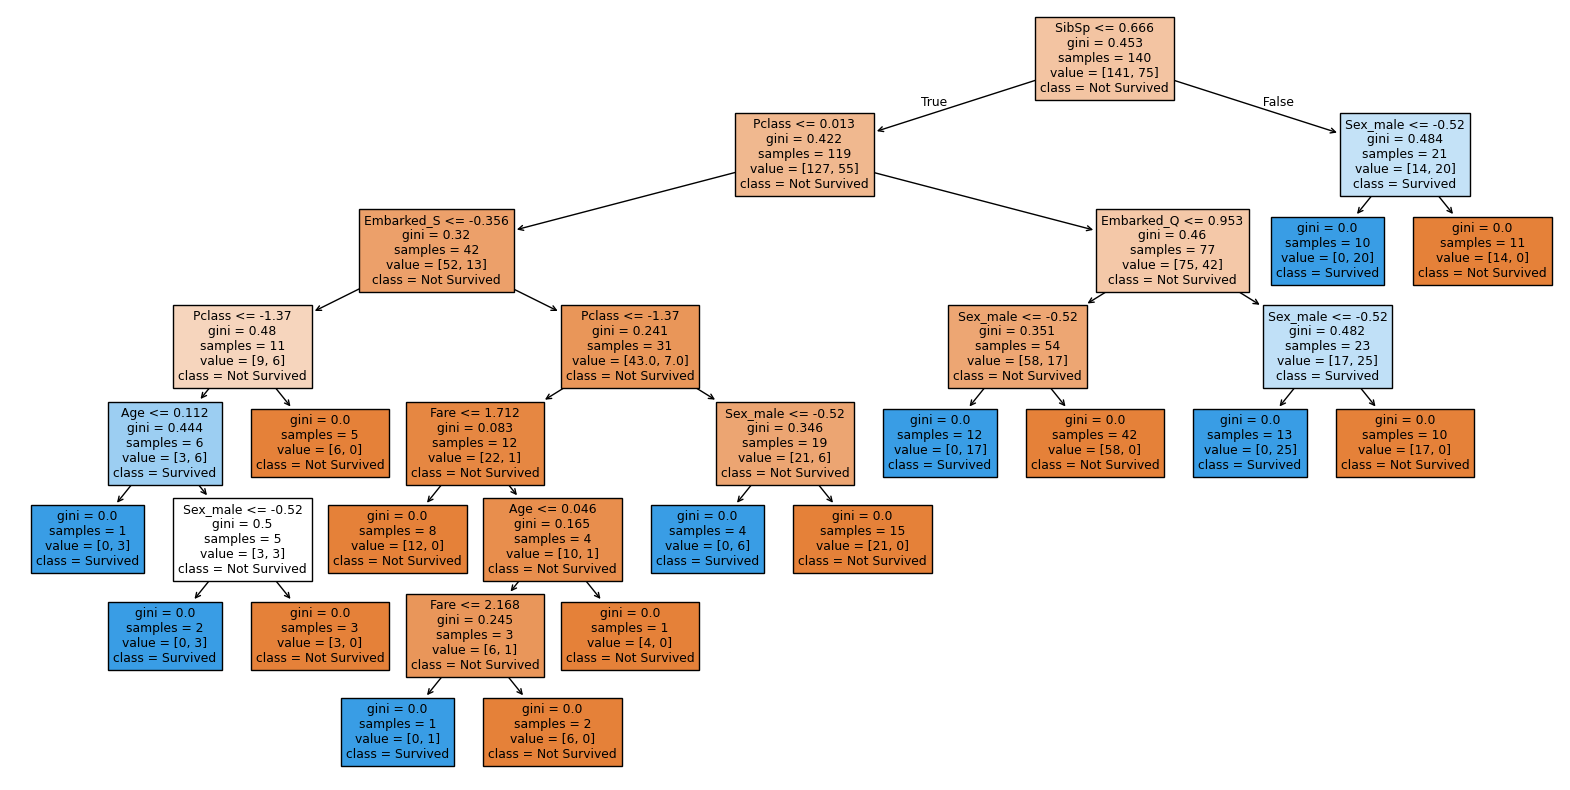

In [119]:
# Import tree visualization
from sklearn import tree
# Plot one tree from forest
plt.figure(figsize=(20,10))

tree.plot_tree(
    model.estimators_[10],
    filled=True,
    feature_names=X.columns,
    class_names=["Not Survived", "Survived"]
)

plt.show()

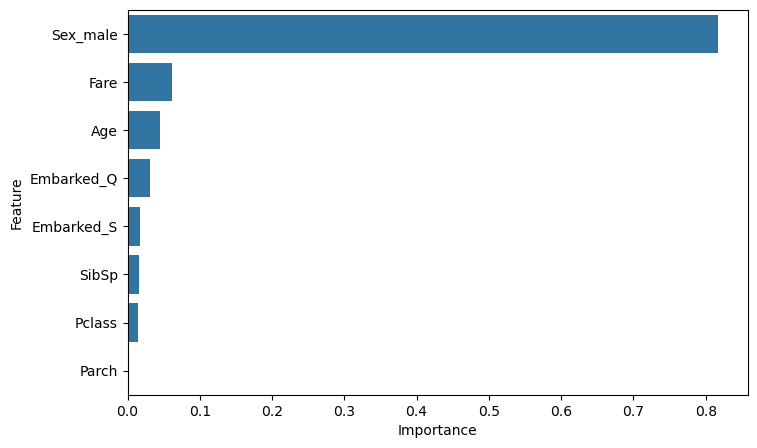

In [120]:
# Plot feature importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(8,5))
sns.barplot(
    x="Importance",
    y="Feature",
    data=importance
)

plt.show()